<a href="https://colab.research.google.com/github/suckgitariuses/PCVK_Ganjil_2025/blob/main/Modul9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MODUL 9 - Morfologi**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, cmap='gray', title=''):
    plt.figure(figsize=(6,6))
    if img.ndim==3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title); plt.axis('off')

**membaca gambar**

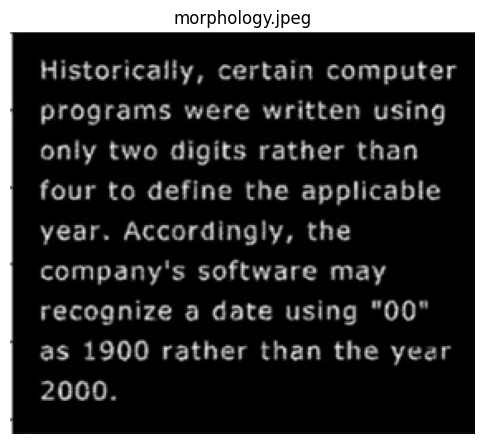

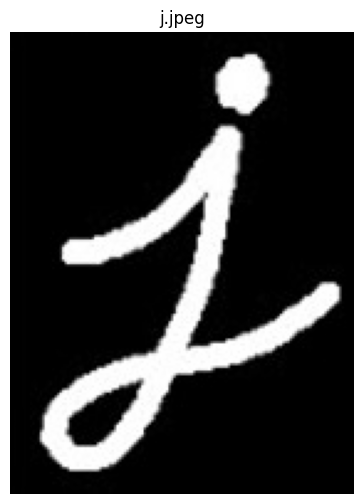

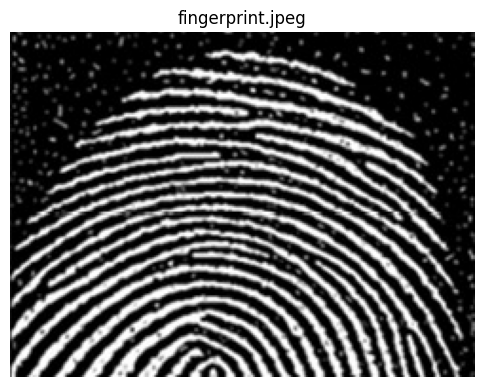

In [10]:
img_morph = cv2.imread('/content/drive/MyDrive/PCVK/Images/morphology.jpeg', cv2.IMREAD_GRAYSCALE)
img_j = cv2.imread('/content/drive/MyDrive/PCVK/Images/j.jpeg', cv2.IMREAD_GRAYSCALE)
img_fp = cv2.imread('/content/drive/MyDrive/PCVK/Images/fingerprint.jpeg', cv2.IMREAD_GRAYSCALE)

show(img_morph, title='morphology.jpeg')
show(img_j, title='j.jpeg')
show(img_fp, title='fingerprint.jpeg')

**membuat structuring element (SE) standar**

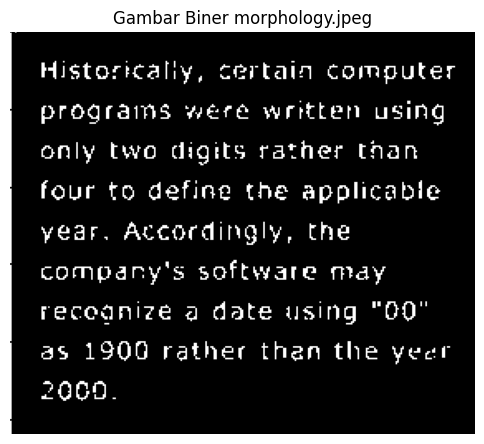

In [15]:
# Binarisasi agar nilainya hanya 0 atau 255
_, img_bin = cv2.threshold(img_morph, 127, 255, cv2.THRESH_BINARY)

# Tampilkan hasil biner
show(img_bin, title='Gambar Biner morphology.jpeg')

In [11]:
# Cross 3x3
se_cross_3 = np.array([[0,1,0],[1,1,1],[0,1,0]], dtype=np.uint8)

# Square 5x5
se_square_5 = np.ones((5,5), dtype=np.uint8)

# Square 3x3
se_square_3 = np.ones((3,3), dtype=np.uint8)

# Circular approx 3x3, 5x5 (menggunakan disk)
def disk_se(radius):
    L = 2*radius+1
    c = radius
    Y, X = np.ogrid[:L, :L]
    mask = (X - c)**2 + (Y - c)**2 <= radius**2
    return mask.astype(np.uint8)
se_circle_3 = disk_se(1)   # 3x3 disk
se_circle_5 = disk_se(2)   # 5x5 disk

# Rectangle 3x5 and 5x7
se_rect_3x5 = np.ones((3,5), dtype=np.uint8)
se_rect_5x7 = np.ones((5,7), dtype=np.uint8)

# Line vertical length 3 and 5
se_line_v3 = np.array([[1],[1],[1]], dtype=np.uint8)
se_line_v5 = np.array([[1],[1],[1],[1],[1]], dtype=np.uint8)

**Implementasi Dilasi Manual (tanpa fungsi morphology OpenCV)**

In [12]:
def dilate_manual(img_bin, se):
    # img_bin: binary 0/255 (uint8)
    img = (img_bin > 0).astype(np.uint8)
    h,w = img.shape
    sh, sw = se.shape
    # pusat SE (floor)
    ph, pw = sh//2, sw//2
    out = np.zeros_like(img)
    # offsets of ones in SE
    offsets = [(i-ph, j-pw) for i in range(sh) for j in range(sw) if se[i,j]]
    for y in range(h):
        for x in range(w):
            if img[y,x]:
                for dy,dx in offsets:
                    ny, nx = y+dy, x+dx
                    if 0 <= ny < h and 0 <= nx < w:
                        out[ny,nx] = 1
    return (out*255).astype(np.uint8)

**Dilasi dengan OpenCV**

SE cross 3x3:
 [[0 1 0]
 [1 1 1]
 [0 1 0]]


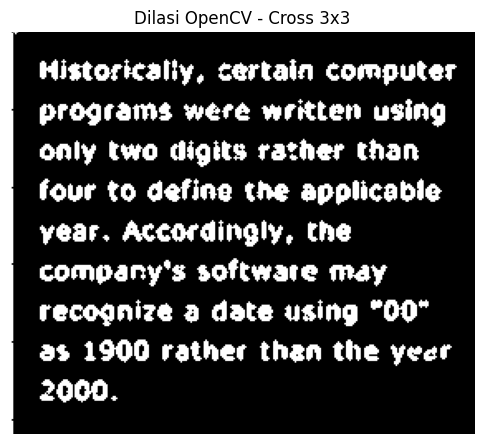

In [16]:
# buat SE cross 3x3 menggunakan OpenCV
se_cv_cross3 = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
print("SE cross 3x3:\n", se_cv_cross3)

res_dilate_cv = cv2.dilate(img_bin, se_cv_cross3, iterations=1)
show(res_dilate_cv, title='Dilasi OpenCV - Cross 3x3')

**Erosi Manual (tanpa OpenCV)**

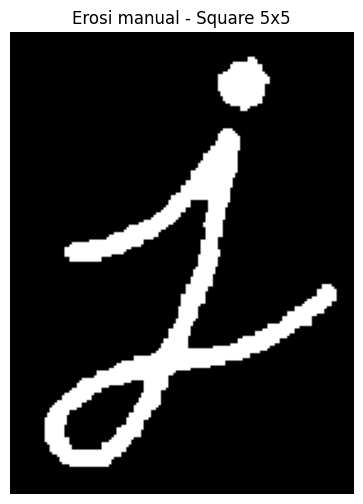

In [17]:
def erode_manual(img_bin, se):
    img = (img_bin > 0).astype(np.uint8)
    h,w = img.shape
    sh, sw = se.shape
    ph, pw = sh//2, sw//2
    out = np.zeros_like(img)
    offsets = [(i-ph, j-pw) for i in range(sh) for j in range(sw) if se[i,j]]
    for y in range(h):
        for x in range(w):
            ok = True
            for dy,dx in offsets:
                ny, nx = y+dy, x+dx
                if not (0 <= ny < h and 0 <= nx < w and img[ny,nx]):
                    ok = False; break
            if ok:
                out[y,x] = 1
    return (out*255).astype(np.uint8)
# Tugas 5: SE square 5x5
res_erode_manual = erode_manual(img_j, se_square_5)
show(res_erode_manual, title='Erosi manual - Square 5x5')

**Erosi dengan OpenCV**

SE square 5x5:
 [[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


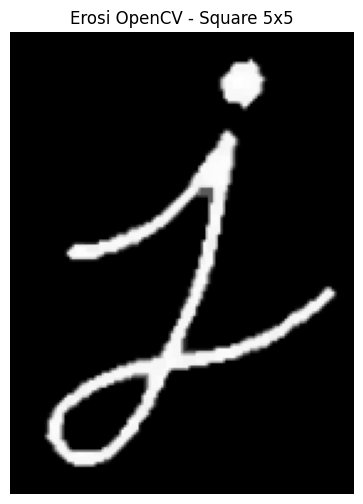

In [18]:
se_cv_sq5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
print("SE square 5x5:\n", se_cv_sq5)

res_erode_cv = cv2.erode(img_j, se_cv_sq5, iterations=1)
show(res_erode_cv, title='Erosi OpenCV - Square 5x5')

**opening tanpa & dengan OpenCV**

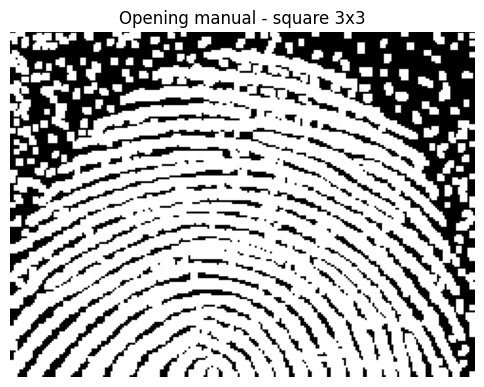

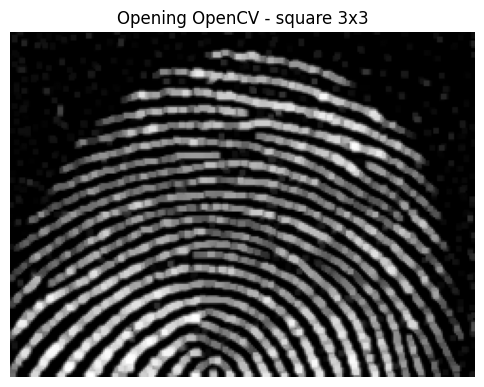

In [19]:
# tanpa OpenCV: erosi manual lalu dilasi manual
open_manual = dilate_manual(erode_manual(img_fp, se_square_3), se_square_3)
show(open_manual, title='Opening manual - square 3x3')

# dengan OpenCV
se_cv_3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
open_cv = cv2.morphologyEx(img_fp, cv2.MORPH_OPEN, se_cv_3)
show(open_cv, title='Opening OpenCV - square 3x3')

**Closing tanpa & dengan OpenCV**

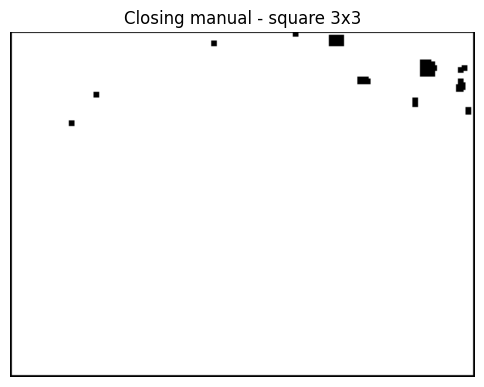

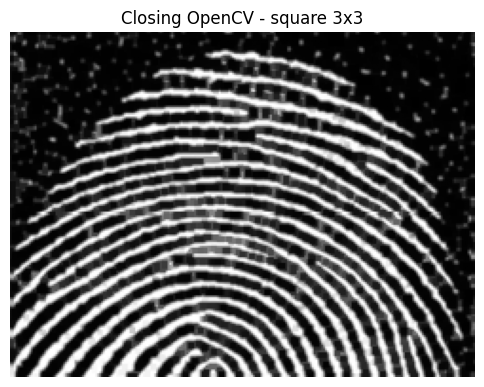

In [20]:
# tanpa OpenCV: dilasi manual lalu erosi manual
close_manual = erode_manual(dilate_manual(img_fp, se_square_3), se_square_3)
show(close_manual, title='Closing manual - square 3x3')

# dengan OpenCV
close_cv = cv2.morphologyEx(img_fp, cv2.MORPH_CLOSE, se_cv_3)
show(close_cv, title='Closing OpenCV - square 3x3')

**Dilasi dengan SE Cross 3x3 dan 5x5**

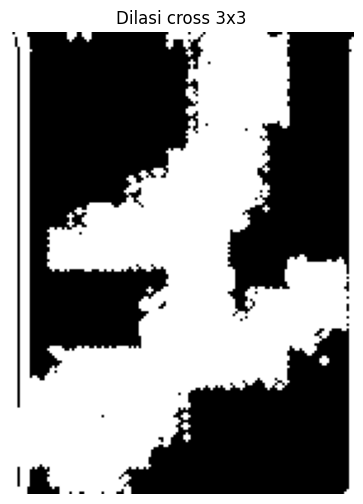

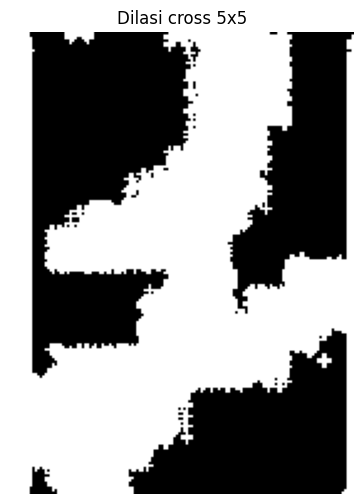

In [21]:
se_cross_5 = np.array([[0,0,1,0,0],
                       [0,0,1,0,0],
                       [1,1,1,1,1],
                       [0,0,1,0,0],
                       [0,0,1,0,0]], dtype=np.uint8)  # contoh cross 5x5
res_cross3 = dilate_manual(img_j, se_cross_3)
res_cross5 = dilate_manual(img_j, se_cross_5)
show(res_cross3, title='Dilasi cross 3x3')
show(res_cross5, title='Dilasi cross 5x5')

**Dilasi dengan SE circular 3x3 dan 5x5**

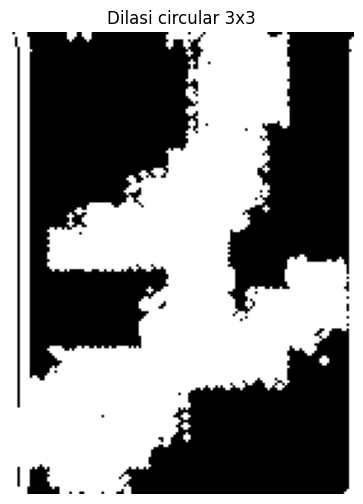

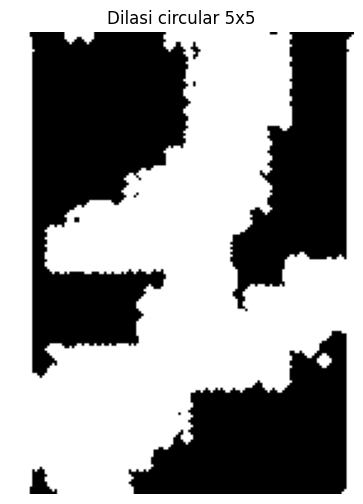

In [22]:
res_circ3 = dilate_manual(img_j, se_circle_3)
res_circ5 = dilate_manual(img_j, se_circle_5)
show(res_circ3, title='Dilasi circular 3x3')
show(res_circ5, title='Dilasi circular 5x5')

**Erosi dengan SE Rectangle 3x5 dan 5x7**

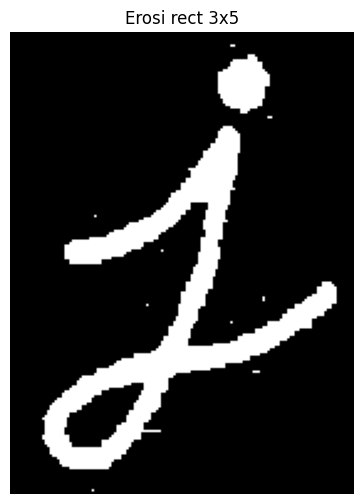

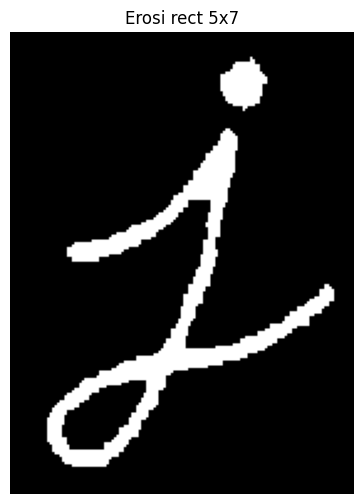

In [23]:
res_rect_3x5 = erode_manual(img_j, se_rect_3x5)
res_rect_5x7 = erode_manual(img_j, se_rect_5x7)
show(res_rect_3x5, title='Erosi rect 3x5')
show(res_rect_5x7, title='Erosi rect 5x7')

# OpenCV alternative:
se_cv_3x5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5,3))  # note order: (width,height)
res_rect_cv = cv2.erode(img_j, se_cv_3x5)

**Erosi dengan Line Vertical 3 dan 5**

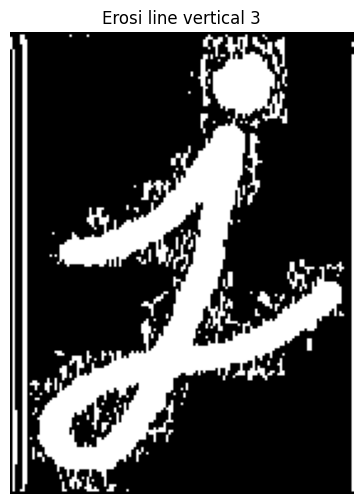

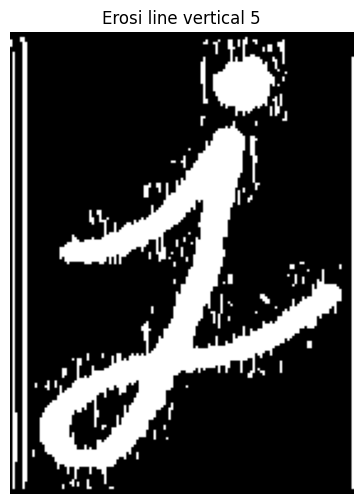

In [24]:
res_line_v3 = erode_manual(img_j, se_line_v3)
res_line_v5 = erode_manual(img_j, se_line_v5)
show(res_line_v3, title='Erosi line vertical 3')
show(res_line_v5, title='Erosi line vertical 5')

# OpenCV version:
se_cv_line3 = cv2.getStructuringElement(cv2.MORPH_RECT, (1,3))
se_cv_line5 = cv2.getStructuringElement(cv2.MORPH_RECT, (1,5))
res_line3_cv = cv2.erode(img_j, se_cv_line3)
res_line5_cv = cv2.erode(img_j, se_cv_line5)